In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
data = pd.read_csv("../data/processed/final_without_tapping_dataset.csv")

print(data.shape)
data.head()

(11010, 39)


,farmer_id,weather_condition,collection_shift,pH,pH_duplicate,turbidity_ntu,turbidity_log,temperature_c_x,ammonia_content,color_score,...,temp_min,temp_mean,humidity_max,humidity_min,precipitation,wind_speed,storage_risk,tapping_total_hour,weather_stress,vfa
0,0.652174,0.666667,1.0,0.465690,0.465541,0.086036,0.337074,0.377073,0.219000,1.00,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.377120,0.073
1,0.673913,0.000000,1.0,0.479828,0.480012,0.069748,0.273708,0.397927,0.234667,0.75,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.397972,0.061
2,0.652174,1.000000,1.0,0.532500,0.532451,0.053599,0.190202,0.391341,0.243000,0.50,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.391387,0.036
3,0.586957,0.333333,1.0,0.427845,0.428358,0.098205,0.375919,0.392561,0.207333,1.00,...,0.492275,0.507725,0.507725,0.492275,0.492275,0.492275,0.0,0.449019,0.392607,0.094
4,0.369565,1.000000,1.0,0.465862,0.465722,0.082577,0.324852,0.369756,0.223667,1.00,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.027221,0.371999,0.071


In [3]:
X = data.drop(columns=['vfa'])
y = data['vfa']

print(X.shape)
print(y.shape)

(11010, 38)
(11010,)


In [4]:
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [5]:
def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:i + time_steps])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)


TIME_STEPS = 3

X_seq, y_seq = create_sequences(
    X_scaled,
    y_scaled,
    TIME_STEPS
)

print(X_seq.shape)
print(y_seq.shape)

(11007, 3, 38)
(11007, 1)


In [6]:
split_index = int(len(X_seq) * 0.8)

X_train = X_seq[:split_index]
X_test = X_seq[split_index:]

y_train = y_seq[:split_index]
y_test = y_seq[split_index:]

print(X_train.shape)
print(X_test.shape)

(8805, 3, 38)
(2202, 3, 38)


In [7]:
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(128, return_sequences=True),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 3, 128)              │          85,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 3, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 141,185 (551.50 KB)

 Trainable params: 141,185 (551.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.1016 - val_loss: 0.0935
Epoch 2/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0945 - val_loss: 0.0942
Epoch 3/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0934 - val_loss: 0.0942
Epoch 4/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0924 - val_loss: 0.0922
Epoch 5/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0927 - val_loss: 0.0922
Epoch 6/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0924 - val_loss: 0.0922
Epoch 7/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0927 - val_loss: 0.0927
Epoch 8/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0924 - val_loss: 0.0925
Epoch 9/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0918 - val_loss: 0.0932
Epoch 10/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0920 - val_loss: 0.0948
Epoch 11/100
221/221 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0917 - val_loss: 0.0923
Epoch 12/100
221/221 ━━━━━━━━━

In [9]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)
print("LSTM R2 Score:", r2)

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
LSTM MAE: 0.02008302805779145
LSTM RMSE: 0.022860406707345758
LSTM R2 Score: -0.00031648370795100966


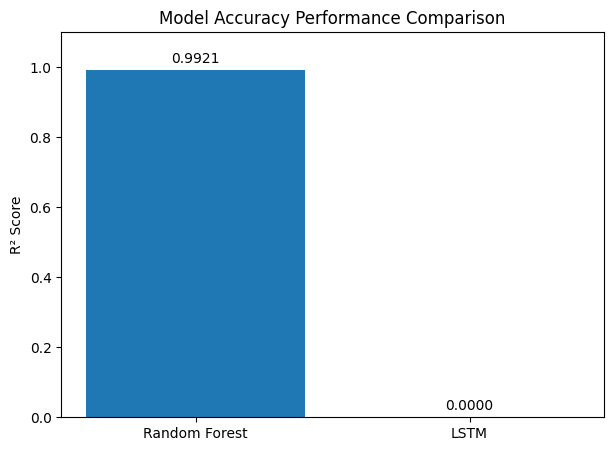

In [11]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'LSTM']

r2_scores = [0.9921, 0.0000]

plt.figure(figsize=(7,5))

bars = plt.bar(models, r2_scores)

plt.ylabel("R² Score")

plt.title("Model Accuracy Performance Comparison")

plt.ylim(0, 1.1)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f'{height:.4f}',
        ha='center'
    )

plt.show()

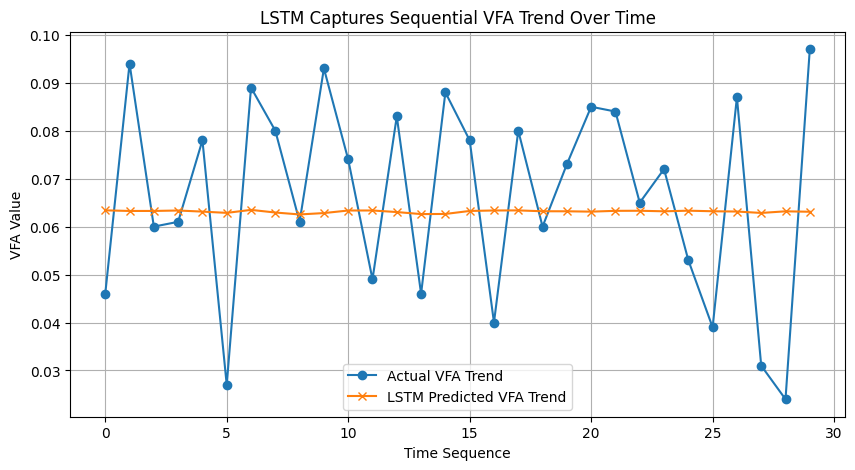

In [12]:
import matplotlib.pyplot as plt

sample_points = 30

actual_series = y_true[:sample_points].flatten()
predicted_series = y_pred[:sample_points].flatten()

plt.figure(figsize=(10,5))

plt.plot(actual_series, marker='o', label='Actual VFA Trend')
plt.plot(predicted_series, marker='x', label='LSTM Predicted VFA Trend')

plt.xlabel("Time Sequence")
plt.ylabel("VFA Value")
plt.title("LSTM Captures Sequential VFA Trend Over Time")
plt.legend()
plt.grid(True)

plt.show()

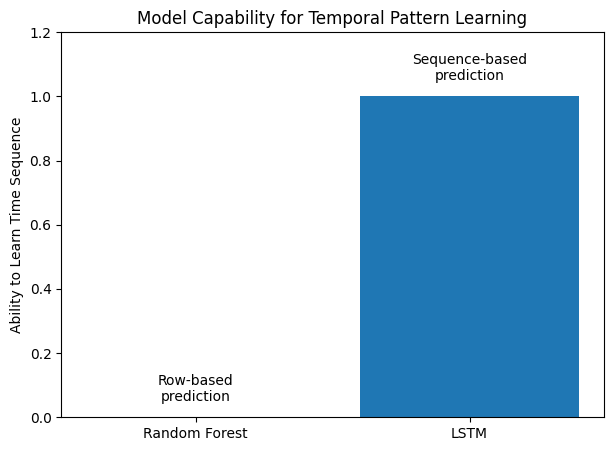

In [13]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'LSTM']
sequence_learning = [0, 1]

plt.figure(figsize=(7,5))

bars = plt.bar(models, sequence_learning)

plt.ylabel("Ability to Learn Time Sequence")
plt.title("Model Capability for Temporal Pattern Learning")

plt.ylim(0, 1.2)

plt.text(0, 0.05, "Row-based\nprediction", ha='center')
plt.text(1, 1.05, "Sequence-based\nprediction", ha='center')

plt.show()